In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import ipywidgets as widget
from XRootD import client
import os
import tqdm

Welcome to JupyROOT 6.28/06


In [2]:
plt.style.use( hep.style.CMS )

In [3]:
bruxPrefix = "root://brux30.hep.brown.edu:1094/"
fileDir = "/store/user/dali/FWLJMET106XUL_singleLep2018UL_RunIISummer20_3t_step2/nominal/"
xrdClient = client.FileSystem( bruxPrefix )
status, dirList = xrdClient.dirlist( fileDir )
samples = [ item.name for item in dirList ]

In [4]:
sampleNames = widget.SelectMultiple( 
    options = sorted( samples ),
    value = [
        "EGamma_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root"
    ]
)
sampleNames

SelectMultiple(index=(6, 59), options=('DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-madgraphMLM-pyth…

In [33]:
fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 500 && minDR_lepJet > 0.2 && isElectron == 1"
fBase += " && ( leptonEta_MultiLepCalc > -1.3 ||  ( leptonPhi_MultiLepCalc < -1.57 || leptonPhi_MultiLepCalc > -0.87 ) )"
variables = [
    "leptonEta_MultiLepCalc",
    "leptonPhi_MultiLepCalc",
]
nTree = "ljmet"
rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
rDir = rPath + "FWLJMET106XUL_singleLep2018UL_RunIISummer20_3t_step3/nominal/"

nDF = {}

for sample_ in sampleNames.value:
    nDF[sample_] = ROOT.RDataFrame( nTree, rDir + sample_ ).Filter( fBase ).AsNumpy( columns = variables )

In [6]:
varPlot = widget.Dropdown( options = variables )
varPlot

Dropdown(options=('leptonEta_MultiLepCalc', 'leptonPhi_MultiLepCalc'), value='leptonEta_MultiLepCalc')

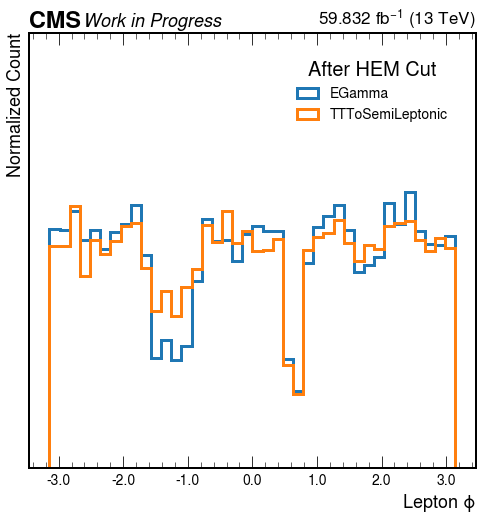

In [35]:
bins = np.linspace( np.min( nDF[sample_][varPlot.value] ), np.max( nDF[sample_][varPlot.value] ), 41 )

plt.figure( figsize = (8,8) )
hep.cms.text( "Work in Progress", fontsize = 18 )
hep.cms.lumitext( "59.832 $fb^{-1}$ (13 TeV)", fontsize = 18 )

for sample_ in sampleNames.value:
    plt.hist( 
        nDF[sample_][varPlot.value], bins = bins, 
        histtype = "step", density = True, 
        label = sample_.split( "_" )[0], lw = 3
    )

plt.ylabel( "Normalized Count", fontsize = 18 )
plt.xlabel( "Lepton $\eta$" if varPlot.value == "leptonEta_MultiLepCalc" else "Lepton $\phi$", fontsize = 18 )

plt.ylim( 0.1, 0.22 )
plt.yticks([])
plt.xticks(np.linspace(-3,3,7),np.linspace(-3,3,7),size=14)

plt.legend( title = "After HEM Cut", title_fontsize = 20, fontsize = 14, borderpad = 1.5 )
plt.show()
plt.close()

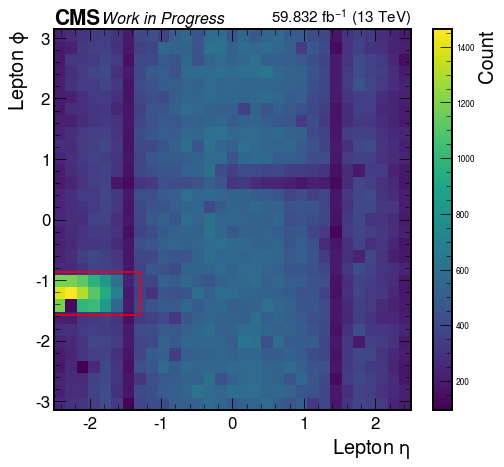

In [8]:
plt.figure( figsize = ( 8, 7 ) )
hep.cms.text( "Work in Progress", fontsize = 16 )
hep.cms.lumitext( "59.832 $fb^{-1}$ (13 TeV)", fontsize = 16 )

plt.hist2d( 
    nDF["EGamma_hadd.root"]["leptonEta_MultiLepCalc"], 
    nDF["EGamma_hadd.root"]["leptonPhi_MultiLepCalc"], 
    bins = 31 
)

plt.colorbar().set_label( label = "Count", size = 20 )
plt.vlines( -1.3, -0.87, -1.57, colors = "red" )
plt.vlines( -2.5, -0.87, -1.57, colors = "red" )
plt.hlines( -1.57, -1.3, -2.5, colors = "red" )
plt.hlines( -0.87, -1.3, -2.5, colors = "red" )
plt.xlabel( "Lepton $\eta$", fontsize = 20 )
plt.ylabel( "Lepton $\phi$", fontsize = 20 )

plt.tick_params( axis = "both", labelsize = 17)

plt.show()
plt.close()

In [12]:
hem_events = []
nom_events = []

for i in range( len( nDF["EGamma_hadd.root"]["leptonPhi_MultiLepCalc"] ) ):
    eta_ = nDF["EGamma_hadd.root"]["leptonEta_MultiLepCalc"][i]
    phi_ = nDF["EGamma_hadd.root"]["leptonPhi_MultiLepCalc"][i]
    if eta_ < -1.3 and ( phi_ > -1.57 and phi_ < -0.87 ):
        hem_events.append( eta_ )
    else:
        nom_events.append( eta_ )

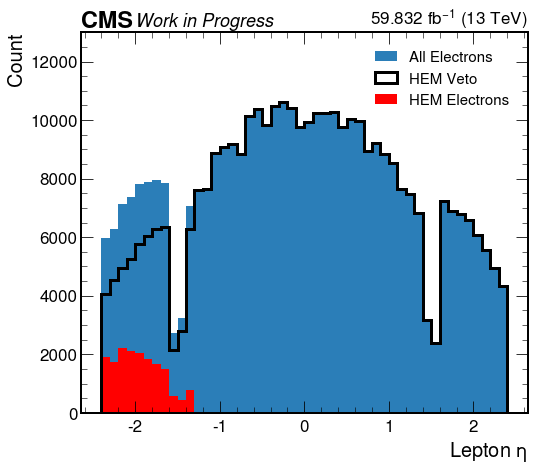

In [31]:
bins = np.linspace(-2.4,2.4,49)

plt.figure( figsize = ( 8, 7 ) )
hep.cms.text( "Work in Progress", fontsize = 18 )
hep.cms.lumitext( "59.832 $fb^{-1}$ (13 TeV)", fontsize = 18 )

plt.hist( nom_events + hem_events, bins = bins, label = "All Electrons", alpha = 0.95 )
plt.hist( nom_events, bins = bins, histtype = "step", color = "k", lw = 3, label = "HEM Veto" )
plt.hist( hem_events, bins = bins, color = "red", label = "HEM Electrons" )

plt.xlabel( "Lepton $\eta$", fontsize = 20 )
plt.ylabel( "Count", fontsize = 20 )

plt.ylim(0,13000)

plt.tick_params( axis = "both", labelsize = 17)

plt.legend( loc = "best", fontsize = 15, borderpad = 0.7 )

plt.show()
plt.close()